In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
# import the parent directory of the current script into the path
import sys
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from pathlib import Path

from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.pipeline import Pipeline

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
sys.path.append("../functions")
from functions import CS_sim_helper

class MultipleTimeSeriesCV:
    """Generates tuples of train_idx, test_idx pairs
    Assumes the MultiIndex contains levels 'symbol' and 'date'
    purges overlapping outcomes"""

    def __init__(self,
                 n_splits=3,
                 train_period_length=126,
                 test_period_length=21,
                 lookahead=None,
                 shuffle=False):
        self.n_splits = n_splits
        self.lookahead = lookahead
        self.test_length = test_period_length
        self.train_length = train_period_length
        self.shuffle = shuffle

    def split(self, X: pd.DataFrame, y: pd.DataFrame = None):
        unique_dates = X.index.get_level_values('date').unique()
        # We reverse the dates so that we will always use the latest dates even if we do not cover all the dates
        days = sorted(unique_dates, reverse=True)

        split_idx = []
        for i in range(self.n_splits):
            test_end_idx = i * self.test_length
            test_start_idx = test_end_idx + self.test_length
            train_end_idx = test_start_idx + self.lookahead - 1
            train_start_idx = train_end_idx + self.train_length + self.lookahead - 1
            split_idx.append([train_start_idx, train_end_idx,
                              test_start_idx, test_end_idx])

        dates = X.reset_index()[['date']]
        for train_start, train_end, test_start, test_end in split_idx:
            if len(days) < train_start:
                break
            train_idx = dates[(dates.date > days[train_start])
                              & (dates.date <= days[train_end])].index
            test_idx = dates[(dates.date > days[test_start])
                             & (dates.date <= days[test_end])].index
            if self.shuffle:
                np.random.shuffle(list(train_idx))
            yield train_idx, test_idx
        
    def get_n_splits(self, X, y):
        return self.n_splits
    
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

def plot_preds_scatter(df, ticker=None):
    if ticker is not None:
        idx = pd.IndexSlice
        df = df.loc[idx[ticker, :], :]
    j = sns.jointplot(x='predicted', y='actuals',
                      robust=True, ci=None,
                      line_kws={'lw': 1, 'color': 'k'},
                      scatter_kws={'s': 1},
                      data=df,
                      kind='reg')
    j.ax_joint.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    j.ax_joint.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
    j.ax_joint.set_xlabel('Predicted')
    j.ax_joint.set_ylabel('Actuals')

def plot_ic_distribution(df, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    
    sns.histplot(df.ic, ax=ax, kde=True)
    mean, median = df.ic.mean(), df.ic.median()
    
    ax.axvline(0, lw=1, ls='--', c='k')
    ax.text(x=0.05, y=0.9,
            s=f'Mean: {mean:8.2f}\nMedian: {median:5.2f}',
            horizontalalignment='left',
            verticalalignment='center',
            transform=ax.transAxes)
    
    ax.set_xlabel('Information Coefficient')
    sns.despine()
    plt.tight_layout()

def plot_rolling_ic(df, error_metric = "rmse",show_year_labels=False, label_every_n_months=2):
    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(14, 8))
    plt.subplots_adjust(hspace=0.3)  # Add more space between subplots

    rolling_result = df.sort_index().rolling(21).mean().dropna()
    mean_ic = df.ic.mean()

    # Plot Information Coefficient
    rolling_result.ic.plot(ax=axes[0],
                           title=f'Information Coefficient (Mean: {mean_ic:.2f})',
                           lw=1)
    axes[0].axhline(0, lw=.5, ls='-', color='k')
    axes[0].axhline(mean_ic, lw=1, ls='--', color='k')

    # Plot Root Mean Squared Error
    mean_error = df[error_metric].mean()
    rolling_result[error_metric].plot(ax=axes[1],
                             title=f'{error_metric} (Mean: {mean_error:.2%})',
                             lw=1,
                             ylim=(0, df[error_metric].max()))
    axes[1].axhline(df[error_metric].mean(), lw=1, ls='--', color='k')

    # Add vertical dashed lines and month labels
    for year in df.index.year.unique():
        for month in range(1, 13, label_every_n_months): 
            month_start = pd.to_datetime(f'{year}-{month}-01')
            for i, ax in enumerate(axes):
                ax.axvline(month_start, color='gray', linestyle='--', linewidth=1)
                if show_year_labels or month == 1:
                    label = f"{month_start.strftime('%b')}\n{month_start.year}" if month == 1 else month_start.strftime('%b')
                    # Adjust label position based on subplot
                    y_pos = ax.get_ylim()[0] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])  
                    ax.text(month_start, y_pos, label, ha='center', va='top')  

    # Formatting
    plt.xlabel("Date")
    sns.despine()



def plot_actuals_predicted(df, symbol, start_date=None, end_date=None, label_every_n_months=3, show_year_labels=True):
    """
    Plots actuals vs. predicted values for a given symbol and date range, adding month labels.

    Args:
        df (pd.DataFrame): DataFrame with 'actuals', 'predicted', 'date', and 'symbol' columns.
        symbol (str): The symbol to plot.
        start_date (str or pd.Timestamp, optional): Start date of the date range (inclusive).
        end_date (str or pd.Timestamp, optional): End date of the date range (inclusive).
        label_every_n_months (int, optional): Label every nth month (default: 3).
        show_year_labels (bool, optional): Whether to show year labels with the first month (default: True).
    """

    # Filter by symbol
    df = df.reset_index()
    df_filtered = df[df['symbol'] == symbol].copy()

    # Convert 'date' column to datetime if necessary
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])

    # Filter by date range if provided
    if start_date:
        df_filtered = df_filtered[df_filtered['date'] >= pd.to_datetime(start_date)]
    if end_date:
        df_filtered = df_filtered[df_filtered['date'] <= pd.to_datetime(end_date)]

    # Plotting with Seaborn
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_filtered, x='date', y='actuals', label='Actuals')
    sns.lineplot(data=df_filtered, x='date', y='predicted', label='Predicted')
    plt.axhline(0, color='black', linestyle='-', linewidth=0.75)
    #plt.axhline(0.5, color='black', linestyle='-', linewidth=0.75)

    plt.title(f'Actuals vs. Predicted for {symbol}')
    plt.xlabel('Date')
    plt.ylabel('Values')
    plt.legend()

    # Add markers for clarity
    sns.scatterplot(data=df_filtered, x='date', y='actuals', color='blue', legend=False)
    sns.scatterplot(data=df_filtered, x='date', y='predicted', color='orange', legend=False)

    # Formatting date axis
    plt.xticks(rotation=45)
    
    # Add vertical dashed lines and month labels
    for year in df_filtered['date'].dt.year.unique():
        for month in range(1, 13, label_every_n_months):
            month_start = pd.to_datetime(f'{year}-{month}-01')
            if month_start >= df_filtered['date'].min() and month_start <= df_filtered['date'].max():
                plt.axvline(month_start, color='gray', linestyle='--', linewidth=1)
                if show_year_labels or month == 1:
                    label = f"{month_start.strftime('%b')}\n{month_start.year}" if month == 1 else month_start.strftime('%b')
                    # Dynamically adjust label position
                    y_pos = plt.gca().get_ylim()[0] - 0.05 * (plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0])
                    plt.text(month_start, y_pos, label, ha='center', va='top')

    plt.tight_layout()
    plt.show()
from time import time


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'CS_toolbox'

# Load the data

In [227]:
start_time = "2021-01-01"
end_time = "2023-12-31"
DATA_STORE = Path('clean_data_biotech/data_assets.h5')
with pd.HDFStore(DATA_STORE) as store:
    df = store['clean_data_biotech/return_factor_fundamental']
# filter the date based on the start_time and end_time
df = df.loc[start_time:end_time]
# lookahead value adjust for the target is moved back, so the training data may contain the test return, we need to skip it.
lookahead = 10
target = f'target_{lookahead}d'
# filter where the target equal to 0, since this is where the target is not available
df = df[df[target] != 0]
# Set the symbol to index so that when we filter, both X and y contain symbol information
df.set_index(["symbol"], inplace=True, append = True)
y = df.filter(like = 'target')
X = df.filter(like = 'feature')
# Filter out any columns that contain ratio
X = X.filter(regex='^(?!.*[Rr][Aa][Tt][Ii][Oo]).*$')
# filter out news_emb
#X = X.filter(regex='^(?!.*[Nn][Ee][Ww][Ss]_[Ee][Mm][Bb]).*$')
return_df = df.filter(regex = 'return|target')
#Standardize the features within each symbol if the column does not contain 'news_emb'
for col in X.columns:
    #if col != 'news_emb':
    # Standardize only columns that are not 'news_emb'
    X[col] = X.groupby('symbol')[col].transform(lambda x: (x - x.mean()) / x.std()) 
#X = X.groupby(level='symbol').transform(lambda x: (x - x.mean()) / x.std())
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
X.drop([c for c in X.columns if 'year' in c], axis=1, inplace=True)


In [109]:
# drop the following duplicated columns: 'feature_totalLiabilitiesAndStockholdersEquity','feature_totalLiabilitiesAndTotalEquity','feature_news_emb_prev_day_127', 'feature_news_emb_prev_day_223'
#X.drop(['feature_totalLiabilitiesAndStockholdersEquity','feature_totalLiabilitiesAndTotalEquity','feature_news_emb_prev_day_127', 'feature_news_emb_prev_day_223'], axis=1, inplace=True)

In [228]:
# maximum number of days for all symbol
max_num_days = df.index.get_level_values("date").unique().__len__()
# number of stocks retained in the dataset
stocks = df.groupby(level = "symbol").size()[df.groupby(level = "symbol").size() == max_num_days].index
num_stock = np.sum(df.groupby(level = "symbol").size() == max_num_days)
print(f"Number of stocks retained in the dataset: {num_stock}")
print(f"Number of days retained in the dataset: {max_num_days}")
X = X.loc[(slice(None), stocks), :]
y = y.loc[(slice(None), stocks), :]
print(y.index.get_level_values("symbol").unique().__len__())


Number of stocks retained in the dataset: 48
Number of days retained in the dataset: 753
48


In [229]:
print(df.index.get_level_values("date").min())
print(df.index.get_level_values("date").max())

2021-01-04 00:00:00
2023-12-29 00:00:00


## Cross validation setup

In [217]:
total_days = y.index.get_level_values('date').unique().shape[0]
train_period_length = 500
test_period_length = 10
n_splits = int(total_days/test_period_length)

cv = MultipleTimeSeriesCV(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)



In [71]:
data = X
train_idx, test_idx = next(cv.split(X=data))
train = data.iloc[train_idx]
train_dates = train.index.get_level_values('date')
test = data.iloc[test_idx]
test_dates = test.index.get_level_values('date')

In [ ]:
df_temp = pd.concat([train.reset_index(), test.reset_index()], axis = 0)

In [42]:
train

feature_calendarYear  feature_revenue_statments  \
date       symbol                                                    
2021-11-22 ABCL               -1.121727                  -0.676202   
           ABUS                0.175583                  -0.067543   
           ACAD                0.182900                   0.227828   
           ACIU                0.180217                  -0.500442   
           ACRS                0.190284                  -0.461306   
...                                 ...                        ...   
2023-11-30 XNCR                1.160125                   0.769312   
           YMAB                1.077204                   1.170068   
           ZLAB                1.126041                   1.123109   
           ZNTL                0.873166                  -0.254438   
           ZYME                1.160427                  -0.053336   

                   feature_costOfRevenue  feature_grossProfit  \
date       symbol                                               
2021-11-22 ABCL                -0.108669            -0.695959   
           ABUS                 1.119232            -0.887554   
           ACAD                 0.038491             0.241413   
           ACIU                 0.759037            -0.578107   
           ACRS                -0.437998            -0.429667   
...                                  ...                  ...   
2023-11-30 XNCR                -0.984674             1.093876   
           YMAB                 1.115145             1.149503   
           ZLAB                 1.178427             1.082496   
           ZNTL                 0.859514            -0.268970   
           ZYME                -0.027653            -0.046160   

                   feature_researchAndDevelopmentExpenses  \
date       symbol                                           
2021-11-22 ABCL                                 -0.997933   
           ABUS                                  0.060704   
           ACAD                                 -0.463550   
           ACIU                                  0.878714   
           ACRS                                 -0.170012   
...                                                   ...   
2023-11-30 XNCR                                  1.522819   
           YMAB                                 -0.511813   
           ZLAB                                 -0.218325   
           ZNTL                                  0.597961   
           ZYME                                 -0.228889   

                   feature_generalAndAdministrativeExpenses  \
date       symbol                                             
2021-11-22 ABCL                                   -0.738464   
           ABUS                                   -0.267822   
           ACAD                                   -1.094034   
           ACIU                                    1.063625   
           ACRS                                   -0.411667   
...                                                     ...   
2023-11-30 XNCR                                    0.886489   
           YMAB                                   -0.672104   
           ZLAB                                    1.004111   
           ZNTL                                    0.873605   
           ZYME                                    0.488840   

                   feature_sellingAndMarketingExpenses  \
date       symbol                                        
2021-11-22 ABCL                              -1.929988   
           ABUS                               0.330983   
           ACAD                              -0.359609   
           ACIU                               0.000000   
           ACRS                              -0.501839   
...                                                ...   
2023-11-30 XNCR                               0.332088   
           YMAB                               0.000000   
           ZLAB                              -0.311933   
          

In [215]:
X.shape

(33300, 509)

In [230]:
# Check the cross validation split
data = X
i = 0
for train_idx, test_idx in cv.split(X=data):
    train = data.iloc[train_idx]
    train_dates = train.index.get_level_values('date')
    test = data.iloc[test_idx]
    test_dates = test.index.get_level_values('date')
    df_temp = pd.concat([train.reset_index(), test.reset_index()], axis = 0)
    n = len(df_temp)
    assert n== len(df_temp.drop_duplicates())
    # if n!= len(df_temp.drop_duplicates()):
    #     print("duplicates")
    print(train.groupby(level='symbol').size().value_counts().index[0],
          train_dates.min().date(), train_dates.max().date(),
          test.groupby(level='symbol').size().value_counts().index[0],
          test_dates.min().date(), test_dates.max().date())
    i += 1
    if i == 5:
        break

509 2021-11-23 2023-12-01 10 2023-12-15 2023-12-29
509 2021-11-09 2023-11-16 10 2023-12-01 2023-12-14
509 2021-10-26 2023-11-02 10 2023-11-16 2023-11-30
509 2021-10-12 2023-10-19 10 2023-11-02 2023-11-15
509 2021-09-28 2023-10-05 10 2023-10-19 2023-11-01


In [20]:
X_train.to_numpy()

array([[ 1.5508767 , -0.62789612, -0.78865958, ...,  0.19664319,
         0.25727003,  1.62768309],
       [ 1.64386371, -0.6129015 , -1.18148976, ...,  0.44938849,
         0.67553212,  1.30544674],
       [ 1.65737433,  1.60371014,  3.19223567, ..., -0.56202698,
         0.22351255, -0.5825305 ],
       ...,
       [ 1.60169626,  2.18181318,  2.18419093, ...,  0.72165278,
         0.35350272,  0.78923729],
       [ 1.61817357, -0.25443839,  0.71961979, ...,  0.06821445,
        -0.02902096, -1.33907743],
       [ 1.65079165, -0.00902368, -1.89507536, ...,  0.28632383,
         0.01049261,  1.1668858 ]])

# Linear regression

In [80]:
import statsmodels.api as sm
class linear_mixed_effect(object):
    def __init__(self):
        pass
    
    def fit(self, X, y):
        # y index contain the grouping variable
        self.group = y.index.get_level_values('symbol')
        self.model = sm.MixedLM(y, X, groups=self.group)
        self.result = self.model.fit()
    
    def predict(self, X, group):
        if not hasattr(self, 'result'):
            raise ValueError("Model has not been fitted yet. Call `fit` first.")
        
        # Get fixed effect contributions
        fixed_effects_params = self.result.params.drop(labels=["Group Var"], errors="ignore")

        fixed_effects = np.dot(X, fixed_effects_params)
        
        # Get random effect contributions
        random_effects = self.result.random_effects
        
        # Map random effects to groups
        random_effect_contrib = np.array([
            np.sum(random_effects.get(grp, 0)) for grp in group
        ])
        
        # Combine fixed and random effects
        predictions = fixed_effects + random_effect_contrib
        return predictions

In [231]:
#%%time
from sklearn.ensemble import RandomForestRegressor
lr_predictions, lr_scores = [], []
lr = LinearRegression()
#lr =  RandomForestRegressor(n_estimators=100)
for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
    X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]
    # df_result = CS_sim_helper.bootstrap_and_CS(L=0.4, level = 0, model = LinearRegression, model_kwargs = {}, 
    #                  X = X_train.to_numpy(), y = y_train.to_numpy(), 
    #                  X_test = X_test.to_numpy(), y_test = y_test.to_numpy(), mean_test_true = y_test.to_numpy(), 
    #                  center_G = True, center_pred = False, closest_point_ind = False, boundary_point_ind = False, 
    #                  use_true_contour = False,  n_boot = 200, pred_y = True, return_plot = False)
    # linear_mix = linear_mixed_effect()
    # linear_mix.fit(X_train, y_train)
    # y_pred_mixed = linear_mix.predict(X_test, group = y_test.index.get_level_values('symbol'))
    y_pred_mixed = None
    print("fitting the model")
    lr.fit(X=X_train, y=y_train)
    y_pred = lr.predict(X_test)
    preds = y_test.to_frame('actuals').assign(predicted=y_pred, predicted_mixed = y_pred_mixed)
    preds_by_day = preds.groupby(level='date')
    scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                               x.actuals)[0] * 100)
                        .to_frame('ic'),
                        preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                y_true=x.actuals)))
                        .to_frame('rmse')], axis=1)

    lr_scores.append(scores)
    lr_predictions.append(preds)
    if i == 10:
        break

lr_scores = pd.concat(lr_scores)
lr_predictions = pd.concat(lr_predictions)

fitting the model
fitting the model
fitting the model
fitting the model
fitting the model
fitting the model
fitting the model
fitting the model
fitting the model
fitting the model


In [232]:
lr_r, lr_p = spearmanr(lr_predictions.actuals, lr_predictions.predicted)
print(f'Information Coefficient (overall): {lr_r:.3%} (p-value: {lr_p:.4%})')

Information Coefficient (overall): -12.411% (p-value: 0.0000%)


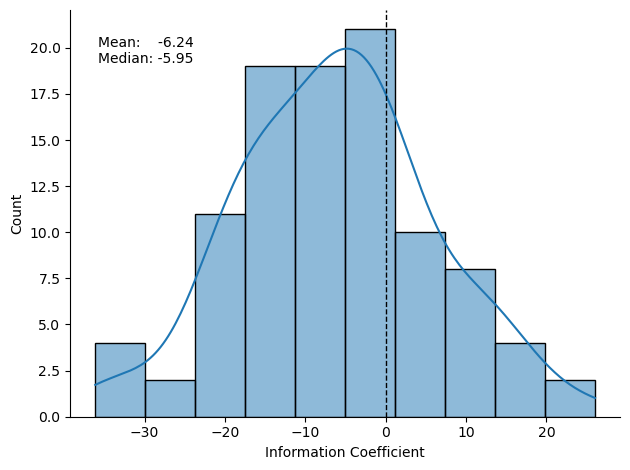

In [233]:
plot_ic_distribution(lr_scores)

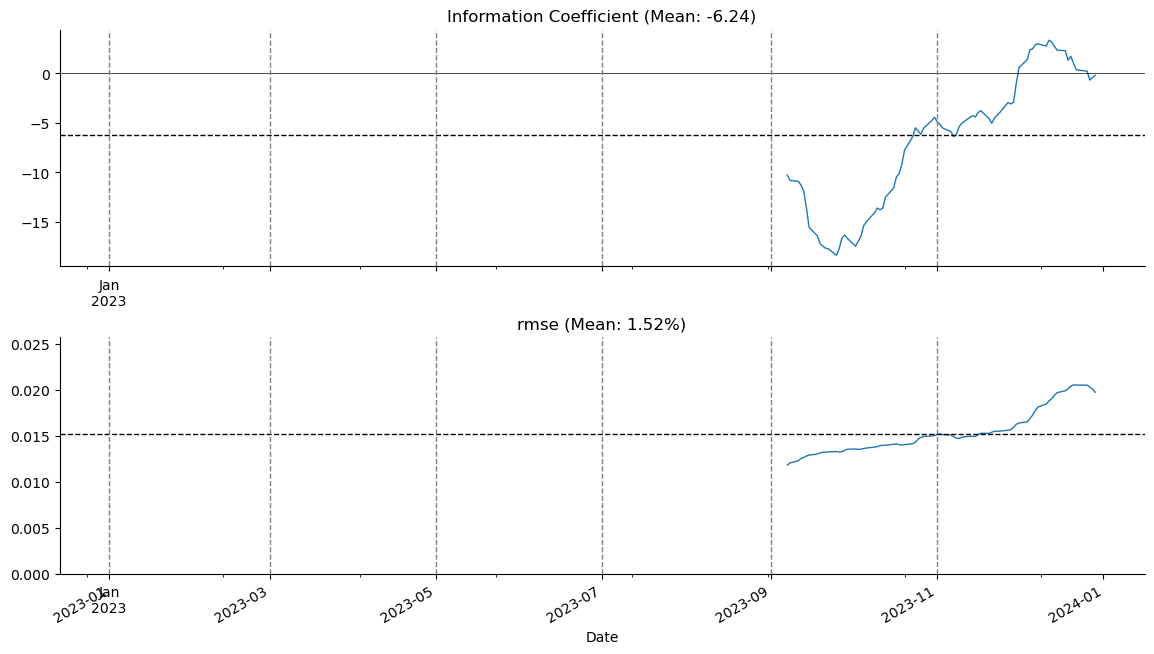

In [234]:
plot_rolling_ic(lr_scores)

In [94]:
lr_predictions.loc[(slice(None),"VRTX"),:]

,,actuals,predicted,predicted_mixed
date,symbol,,,
2024-11-27,VRTX,-0.000095,0.001098,None
2024-11-29,VRTX,-0.000944,0.000884,None
2024-12-02,VRTX,0.000506,0.005846,None
2024-12-03,VRTX,0.002653,0.006132,None
2024-12-04,VRTX,-0.003610,0.005625,None
...,...,...,...,...
2020-12-29,VRTX,-0.002771,0.005658,None
2020-12-30,VRTX,-0.002856,0.005665,None
2020-12-31,VRTX,-0.004662,0.005785,None


In [42]:
idx = pd.IndexSlice
lr_predictions.loc[idx[:,"VRTX"],:]

,,actuals,predicted,predicted_mixed
date,symbol,,,
2024-11-13,VRTX,-0.006248,-0.002445,None
2024-11-14,VRTX,-0.003320,0.002374,None
2024-11-15,VRTX,0.000006,0.002613,None
2024-11-18,VRTX,-0.002171,0.002686,None
2024-11-19,VRTX,0.003509,-0.003708,None
...,...,...,...,...
2024-08-13,VRTX,0.002686,-0.000575,None
2024-08-14,VRTX,0.003813,0.001088,None
2024-08-15,VRTX,0.004434,0.001048,None


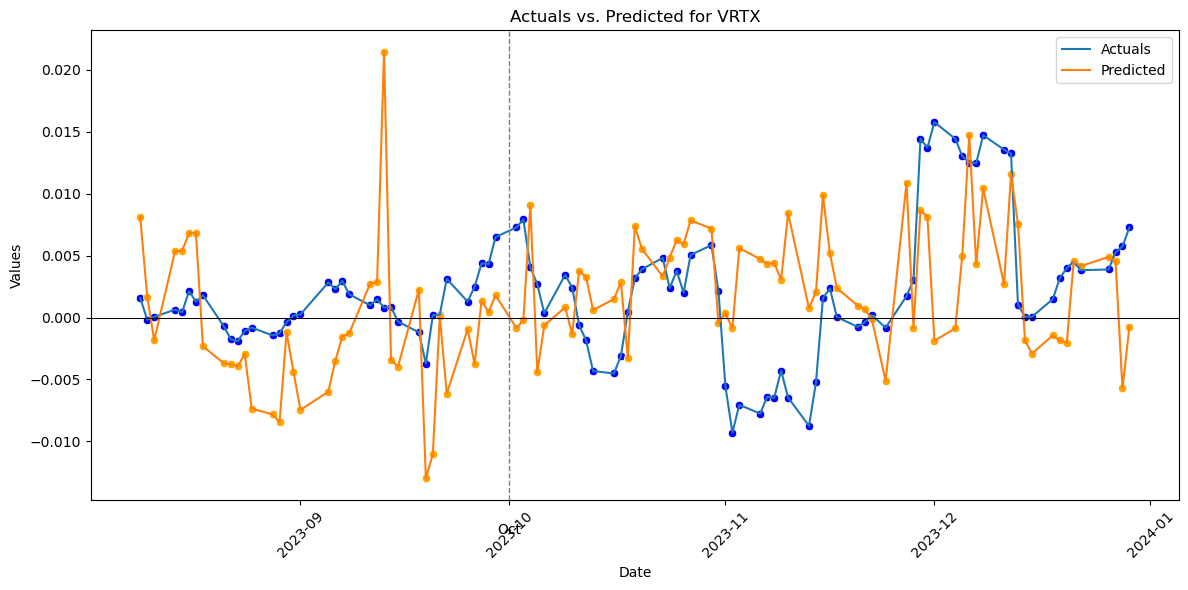

In [235]:
plot_actuals_predicted(lr_predictions, symbol = "VRTX", start_date = lr_predictions.index.get_level_values("date").min(), end_date=lr_predictions.index.get_level_values("date").max())

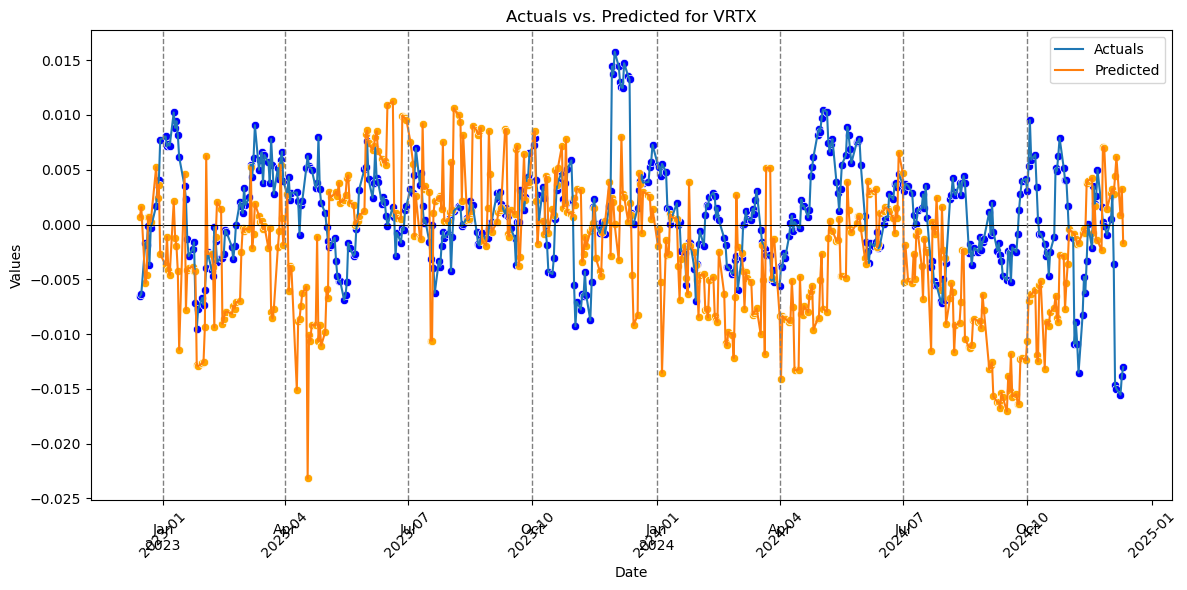

In [106]:
# drop predicted_ and rename lr_predictions.predicted_mixed to predicted  
lr_predictions.drop(columns = ['predicted'], inplace = True)
lr_predictions.rename(columns = {'predicted_mixed':'predicted'}, inplace = True)
plot_actuals_predicted(lr_predictions, symbol = "VRTX", start_date = lr_predictions.index.get_level_values("date").min(), end_date=lr_predictions.index.get_level_values("date").max())

# Ridge regression

In [10]:
ridge_alphas = np.logspace(-4, 2, 6)
ridge_alphas = sorted(list(ridge_alphas) + list(ridge_alphas * 5))

In [14]:
ridge_coeffs, ridge_scores, ridge_predictions = {}, [], []

for alpha in ridge_alphas:
    print(alpha, end=' ', flush=True)
    model = Ridge(alpha=alpha,
                  fit_intercept=False,
                  random_state=42)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)])

    coeffs = []
    for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]

        pipe.fit(X=X_train, y=y_train)
        y_pred = pipe.predict(X_test)

        preds = y_test.to_frame('actuals').assign(predicted=y_pred)
        preds_by_day = preds.groupby(level='date')
        scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                                   x.actuals)[0] * 100)
                            .to_frame('ic'),
                            preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                    y_true=x.actuals)))
                            .to_frame('rmse')], axis=1)

        ridge_scores.append(scores.assign(alpha=alpha))
        ridge_predictions.append(preds.assign(alpha=alpha))

        coeffs.append(pipe.named_steps['model'].coef_)
    ridge_coeffs[alpha] = np.mean(coeffs, axis=0)

print('\n')

0.0001 

/tmp/ipykernel_17498/3483120490.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,


0.0005 

/tmp/ipykernel_17498/3483120490.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,


0.001584893192461114 

...

/tmp/ipykernel_17498/3483120490.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,


100.0 

/tmp/ipykernel_17498/3483120490.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,


500.0 

/tmp/ipykernel_17498/3483120490.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,


In [20]:
ridge_scores = pd.concat(ridge_scores)
ridge_coeffs = pd.DataFrame(ridge_coeffs, index=X.columns).T
ridge_predictions = pd.concat(ridge_predictions)
ridge_r, ridge_p = spearmanr(ridge_predictions.actuals, ridge_predictions.predicted)

TypeError: first argument must be an iterable of pandas objects, you passed an object of type "DataFrame"

In [21]:
print(f'Information Coefficient (overall): {ridge_r:.3%} (p-value: {ridge_p:.4%})')

Information Coefficient (overall): 3.850% (p-value: 0.0000%)


In [22]:
ridge_scores.to_hdf(DATA_STORE, 'ridge/scores')
ridge_predictions.to_hdf(DATA_STORE, 'ridge/predictions')
ridge_coeffs.to_hdf(DATA_STORE, 'ridge/coeffs')

/tmp/ipykernel_17498/3964829454.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  ridge_scores.to_hdf(DATA_STORE, 'ridge/scores')
/tmp/ipykernel_17498/3964829454.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  ridge_predictions.to_hdf(DATA_STORE, 'ridge/predictions')
/tmp/ipykernel_17498/3964829454.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  ridge_coeffs.to_hdf(DATA_STORE, 'ridge/coeffs')


In [ ]:
ridge_scores = pd.read_hdf(DATA_STORE, 'ridge/scores')
ridge_coeffs = pd.read_hdf(DATA_STORE, 'ridge/coeffs')
ridge_predictions = pd.read_hdf(DATA_STORE, 'ridge/predictions')

In [16]:
ridge_scores.groupby('alpha').ic.describe()

,count,mean,std,min,25%,50%,75%,max
alpha,,,,,,,,
0.000100,1840.0,5.233449,9.123295,-26.923491,-0.711956,5.400245,10.908982,39.277690
0.000500,1840.0,5.229885,9.120591,-26.947756,-0.701761,5.397621,10.906398,39.263275
0.001585,1840.0,5.230500,9.119475,-26.943427,-0.707008,5.412816,10.952112,39.249725
0.007924,1840.0,5.235052,9.121369,-26.916419,-0.649653,5.395970,10.954211,39.216186
0.025119,1840.0,5.238714,9.125030,-26.836369,-0.671277,5.397548,10.967038,39.253761
0.125594,1840.0,5.243692,9.127745,-26.817713,-0.655448,5.394441,10.931586,39.264620
0.398107,1840.0,5.247419,9.130255,-26.784791,-0.642272,5.404708,10.928636,39.328239
1.990536,1840.0,5.244233,9.151576,-26.974884,-0.732757,5.387398,10.948103,39.453073
6.309573,1840.0,5.231006,9.180499,-27.503758,-0.840672,5.353987,10.995872,39.605969


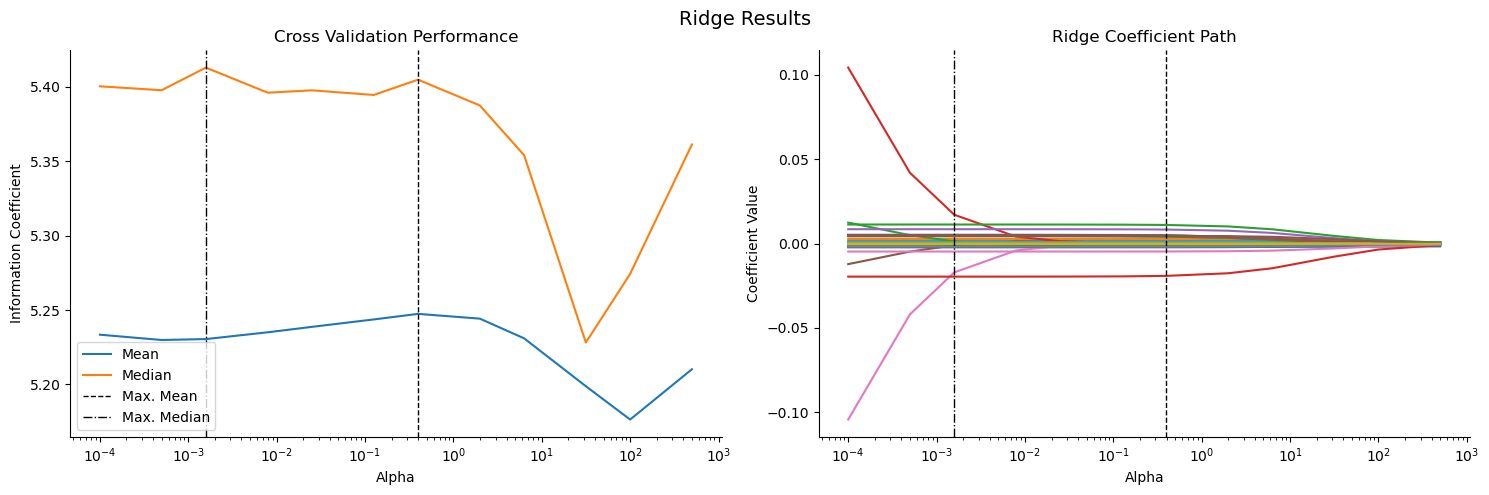

In [43]:
fig, axes = plt.subplots(ncols=2, sharex=True, figsize=(15, 5))

scores_by_alpha = ridge_scores.groupby('alpha').ic.agg(['mean', 'median'])
best_alpha_mean = scores_by_alpha['mean'].idxmax()
best_alpha_median = scores_by_alpha['median'].idxmax()
aggregated_data = ridge_scores.groupby('alpha')['ic'].mean().reset_index()

ax = sns.lineplot(x='alpha',
                  y='ic',
                  data=aggregated_data,
                  estimator=np.mean,
                  label='Mean',
                  ax=axes[0])

scores_by_alpha['median'].plot(logx=True,
                               ax=axes[0],
                               label='Median')

axes[0].axvline(best_alpha_mean,
                ls='--',
                c='k',
                lw=1,
                label='Max. Mean')
axes[0].axvline(best_alpha_median,
                ls='-.',
                c='k',
                lw=1,
                label='Max. Median')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Information Coefficient')
axes[0].set_title('Cross Validation Performance')

ridge_coeffs.plot(logx=True,
                  legend=False,
                  ax=axes[1],
                  title='Ridge Coefficient Path')

axes[1].axvline(best_alpha_mean,
                ls='--',
                c='k',
                lw=1,
                label='Max. Mean')
axes[1].axvline(best_alpha_median,
                ls='-.',
                c='k',
                lw=1,
                label='Max. Median')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')

fig.suptitle('Ridge Results', fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

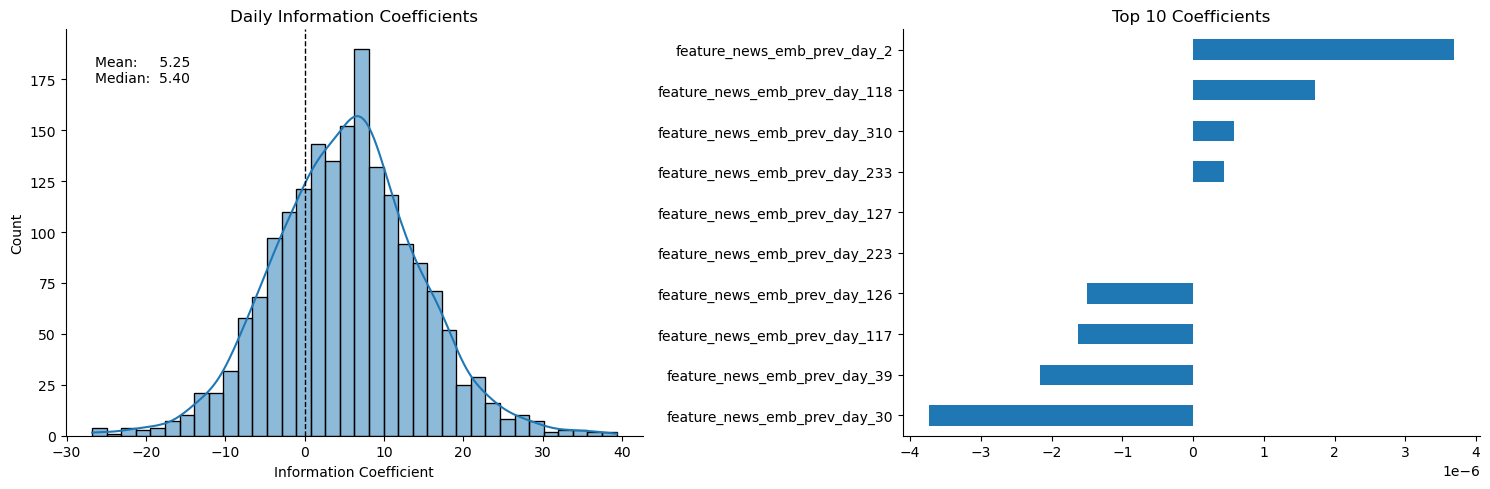

In [117]:
best_alpha = ridge_scores.groupby('alpha').ic.mean().idxmax()
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
plot_utility.plot_ic_distribution(ridge_scores[ridge_scores.alpha == best_alpha],
                     ax=axes[0])
axes[0].set_title('Daily Information Coefficients')
top_coeffs = ridge_coeffs.loc[best_alpha].abs().sort_values().head(10).index
top_coeffs.tolist()
ridge_coeffs.loc[best_alpha, top_coeffs].sort_values().plot.barh(ax=axes[1],
                                                                 title='Top 10 Coefficients')
sns.despine()
fig.tight_layout()

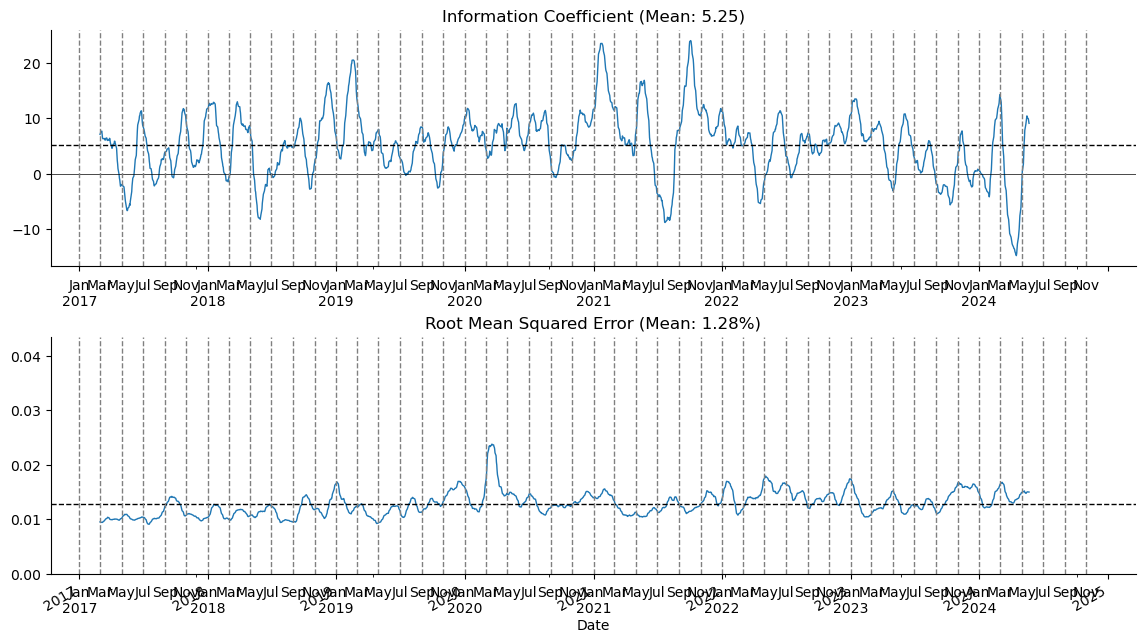

In [118]:
plot_utility.plot_rolling_ic(ridge_scores[ridge_scores.alpha==best_alpha])

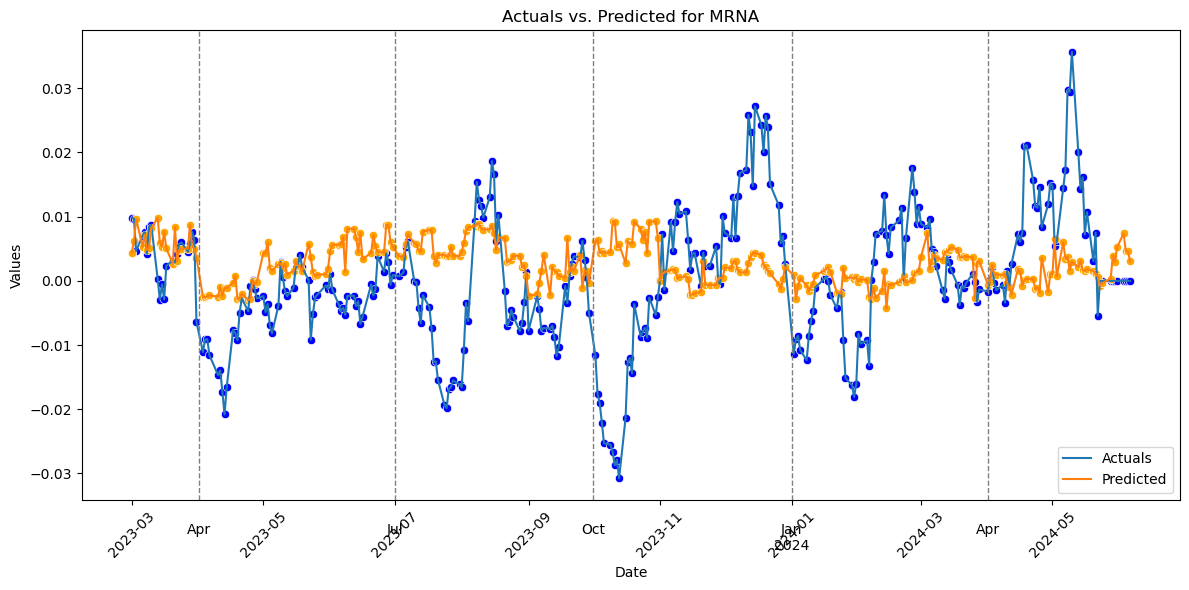

In [142]:
plot_utility.plot_actuals_predicted(ridge_predictions[ridge_predictions.alpha==best_alpha], symbol = "MRNA", start_date = '2023-03', end_date='2024-07')

# Lasso regression

In [ ]:
lasso_alphas = np.logspace(-10, -3, 8)
lasso_coeffs, lasso_scores, lasso_predictions = {}, [], []
for alpha in lasso_alphas:
    print(alpha, end=' ', flush=True)
    model = Lasso(alpha=alpha,
                  fit_intercept=False,  # StandardScaler centers data
                  random_state=42,
                  tol=1e-3,
                  max_iter=1000,
                  warm_start=True,
                  selection='random')

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)])
    coeffs = []
    for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        t = time()
        X_train, y_train, = X.iloc[train_idx], y[target].iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y[target].iloc[test_idx]

        pipe.fit(X=X_train, y=y_train)
        y_pred = pipe.predict(X_test)

        preds = y_test.to_frame('actuals').assign(predicted=y_pred)
        preds_by_day = preds.groupby(level='date')
        scores = pd.concat([preds_by_day.apply(lambda x: spearmanr(x.predicted,
                                                                   x.actuals)[0] * 100)
                            .to_frame('ic'),
                            preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(y_pred=x.predicted,
                                                                                    y_true=x.actuals)))
                            .to_frame('rmse')],
                           axis=1)

        lasso_scores.append(scores.assign(alpha=alpha))
        lasso_predictions.append(preds.assign(alpha=alpha))

        coeffs.append(pipe.named_steps['model'].coef_)

    lasso_coeffs[alpha] = np.mean(coeffs, axis=0)

In [28]:
lasso_scores = pd.concat(lasso_scores)
lasso_coeffs = pd.DataFrame(lasso_coeffs, index=X.columns).T
lasso_predictions = pd.concat(lasso_predictions)


In [72]:
best_alpha = lasso_scores.groupby('alpha').ic.mean().idxmax()
preds = lasso_predictions[lasso_predictions.alpha==best_alpha]
lasso_r, lasso_p = spearmanr(preds.actuals, preds.predicted)


In [30]:
print(f'Information Coefficient (overall): {lasso_r:.3%} (p-value: {lasso_p:.4%})')

Information Coefficient (overall): 5.764% (p-value: 0.0000%)


In [31]:
lasso_scores.to_hdf(DATA_STORE, 'lasso/scores')
lasso_coeffs.to_hdf(DATA_STORE, 'lasso/coeffs')
lasso_predictions.to_hdf(DATA_STORE, 'lasso/predictions')

/tmp/ipykernel_17498/3914359398.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  lasso_scores.to_hdf(DATA_STORE, 'lasso/scores')
/tmp/ipykernel_17498/3914359398.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  lasso_coeffs.to_hdf(DATA_STORE, 'lasso/coeffs')
/tmp/ipykernel_17498/3914359398.py:3: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  lasso_predictions.to_hdf(DATA_STORE, 'lasso/predictions')


In [32]:
lasso_scores.groupby('alpha').ic.agg(['mean', 'median'])

,mean,median
alpha,,
1.000000e-10,5.298257,5.435053
1.000000e-09,5.298350,5.432305
1.000000e-08,5.298358,5.436284
1.000000e-07,5.299131,5.432659
1.000000e-06,5.298433,5.419012
1.000000e-05,5.692980,5.620535
1.000000e-04,7.583570,7.771723
1.000000e-03,7.940067,8.497766


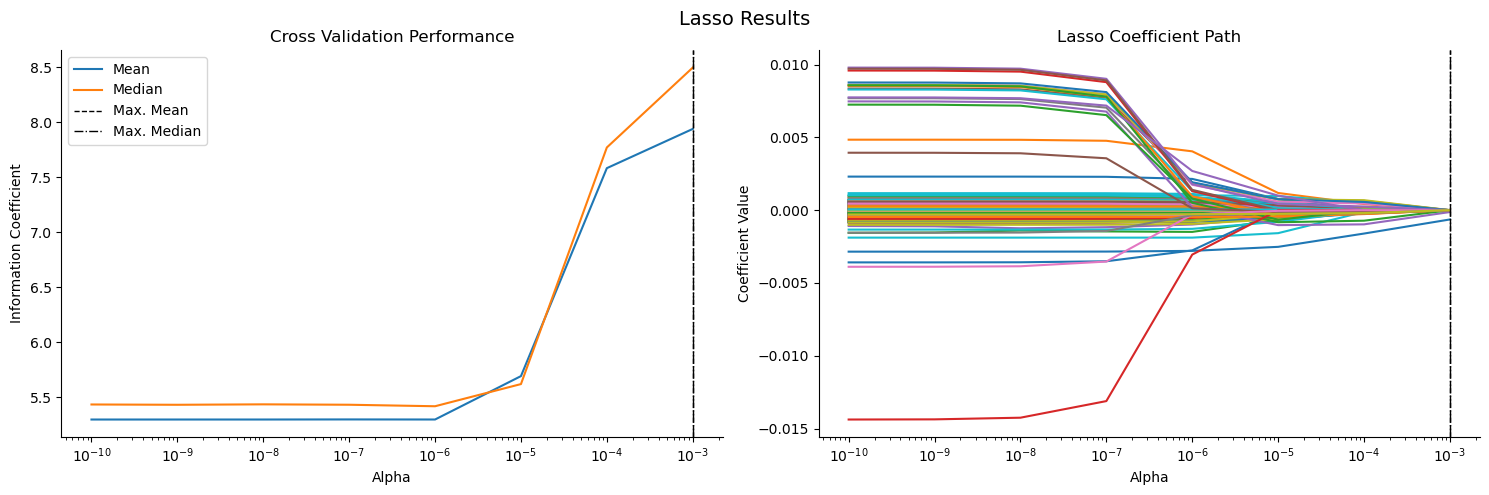

In [46]:
fig, axes = plt.subplots(ncols=2, sharex=True, figsize=(15, 5))

scores_by_alpha = lasso_scores.groupby('alpha').ic.agg(['mean', 'median'])
best_alpha_mean = scores_by_alpha['mean'].idxmax()
best_alpha_median = scores_by_alpha['median'].idxmax()
aggregated_data = lasso_scores.groupby('alpha')['ic'].mean().reset_index()

ax = sns.lineplot(x='alpha', y='ic', data=aggregated_data, estimator=np.mean, label='Mean', ax=axes[0])

scores_by_alpha['median'].plot(logx=True, ax=axes[0], label='Median')

axes[0].axvline(best_alpha_mean, ls='--', c='k', lw=1, label='Max. Mean')
axes[0].axvline(best_alpha_median, ls='-.', c='k', lw=1, label='Max. Median')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Information Coefficient')
axes[0].set_title('Cross Validation Performance')

lasso_coeffs.plot(logx=True, legend=False, ax=axes[1], title='Lasso Coefficient Path')
axes[1].axvline(best_alpha_mean, ls='--', c='k', lw=1, label='Max. Mean')
axes[1].axvline(best_alpha_median, ls='-.', c='k', lw=1, label='Max. Median')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Coefficient Value')

fig.suptitle('Lasso Results', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=.9)
sns.despine()

In [136]:
best_alpha = 1.000000e-05	
lasso_coeffs.loc[best_alpha]

feature_calendarYear                      0.00046210271810006784
feature_revenue_statments                -0.00001379819788567534
feature_costOfRevenue                    -0.00005652483934948370
feature_grossProfit                       0.00045751742074482348
feature_researchAndDevelopmentExpenses    0.00015960571208613667
                                                   ...          
feature_LowerBB                           0.00100196704336028030
feature_macd                             -0.00011164603756571015
feature_macd_signal                      -0.00004539278335299363
feature_macd_hist                        -0.00024557968310422851
feature_BB%                              -0.00025267442089503550
Name: 1e-05, Length: 509, dtype: float64

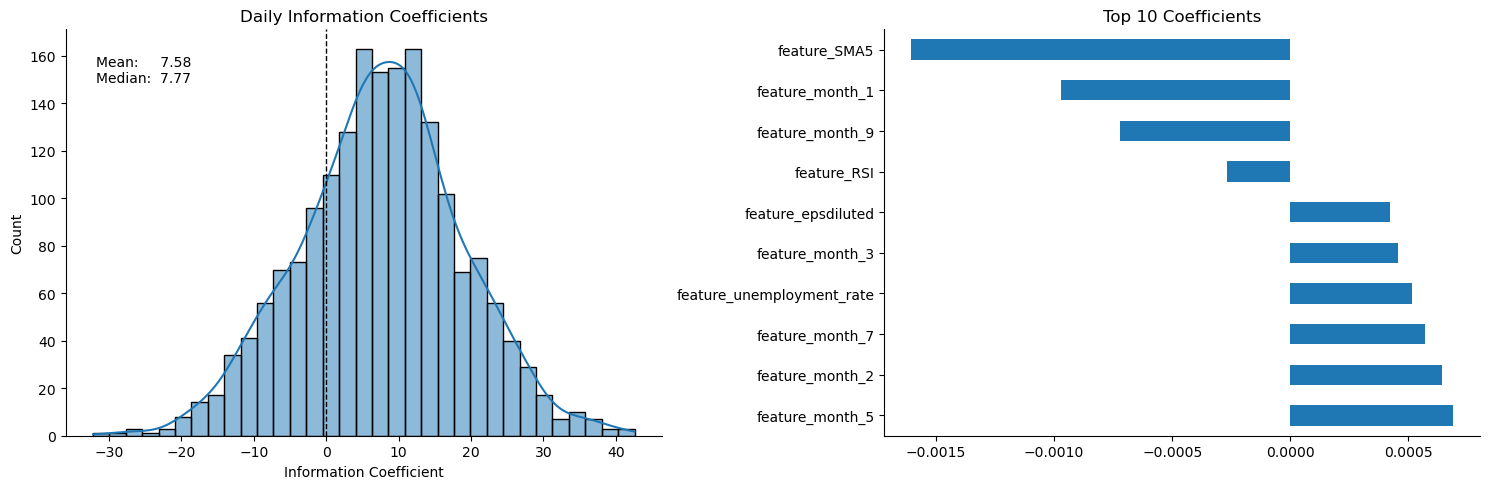

In [137]:
#best_alpha = lasso_scores.groupby('alpha').ic.mean().idxmax()
best_alpha = 1.000000e-04	
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
plot_utility.plot_ic_distribution(lasso_scores[lasso_scores.alpha==best_alpha], ax=axes[0])
axes[0].set_title('Daily Information Coefficients')

top_coeffs = lasso_coeffs.loc[best_alpha].abs().sort_values(ascending=False).head(10).index
top_coeffs.tolist()
lasso_coeffs.loc[best_alpha, top_coeffs].sort_values(ascending=False).plot.barh(ax=axes[1], title='Top 10 Coefficients')

sns.despine()
fig.tight_layout()

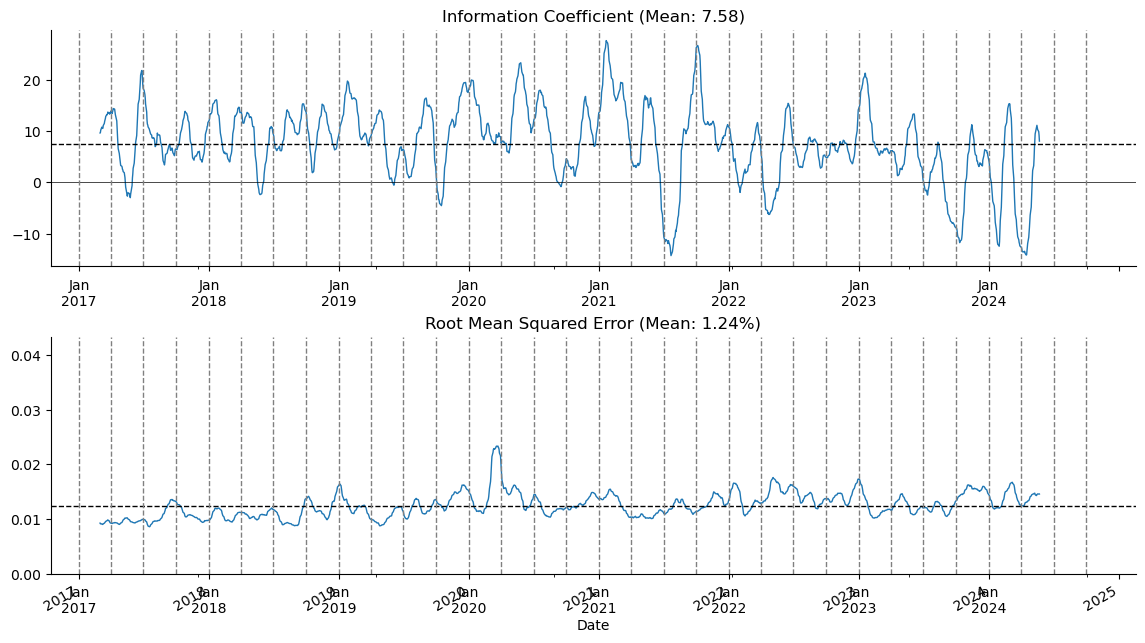

In [138]:
plot_utility.plot_rolling_ic(lasso_scores[lasso_scores.alpha==best_alpha], label_every_n_months=3)

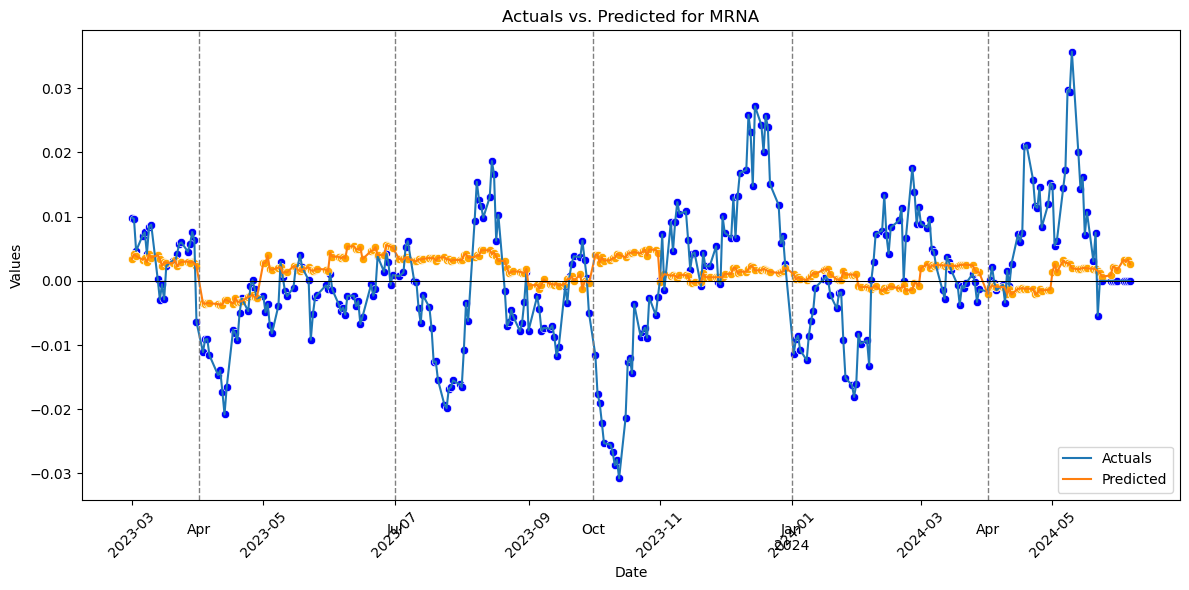

In [143]:
plot_utility.plot_actuals_predicted(lasso_predictions[lasso_predictions.alpha==best_alpha], symbol = "MRNA", start_date = '2023-03', end_date='2024-07')

# Compare results

In [92]:
best_ridge_alpha = ridge_scores.groupby('alpha').ic.mean().idxmax()
best_ridge_preds = ridge_predictions[ridge_predictions.alpha==best_ridge_alpha]
best_ridge_scores = ridge_scores[ridge_scores.alpha==best_ridge_alpha]

best_lasso_alpha = 0.0001#lasso_scores.groupby('alpha').ic.mean().idxmax()
best_lasso_preds = lasso_predictions[lasso_predictions.alpha==best_lasso_alpha]
best_lasso_scores = lasso_scores[lasso_scores.alpha==best_lasso_alpha]

df = pd.concat([lr_scores.assign(Model='Linear Regression'),
               best_ridge_scores.assign(Model='Ridge Regression'),
               best_lasso_scores.assign(Model='Lasso Regression')]).drop('alpha', axis=1)
df.columns = ['IC', 'RMSE', 'Model']

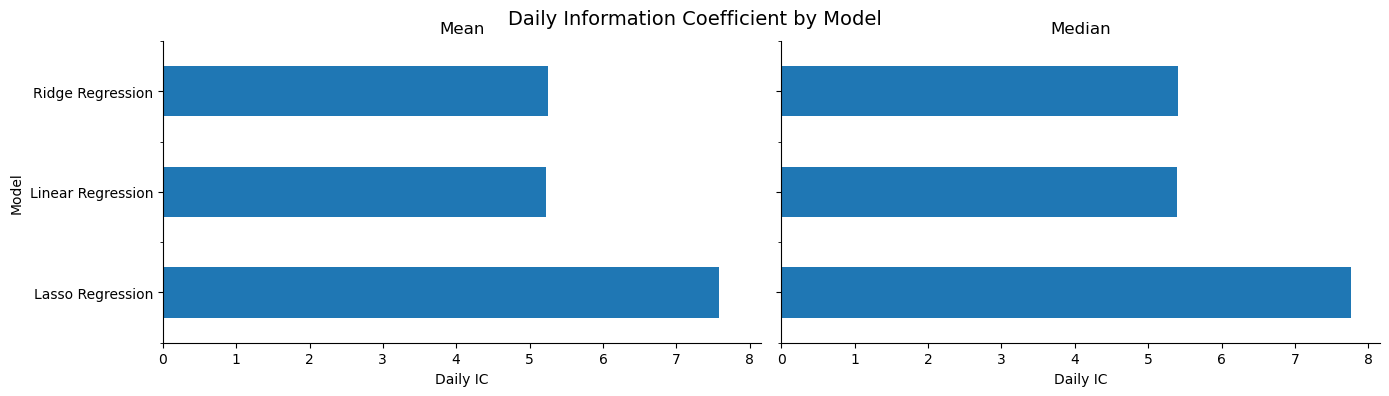

In [93]:
scores = df.groupby('Model').IC.agg(['mean', 'median'])
fig, axes = plt.subplots(ncols=2, figsize=(14,4), sharey=True, sharex=True)

scores['mean'].plot.barh(ax=axes[0],  title='Mean')
scores['median'].plot.barh(ax=axes[1],title='Median')
axes[0].set_xlabel('Daily IC')
axes[1].set_xlabel('Daily IC')

fig.suptitle('Daily Information Coefficient by Model', fontsize=14)
sns.despine()
fig.tight_layout()
fig.subplots_adjust(top=.9)

# Logistic regression to predict price movement

In [144]:
y

,,target_1d,target_5d,target_10d
date,symbol,,,
2014-09-02,A,0.00000000000000000000,-0.00215247691765907412,-0.00026167749967120901
2014-09-03,A,-0.00653423941453212809,-0.00131027703865405076,0.00140251086143972081
2014-09-04,A,0.00394632991318077941,-0.00031590592311625532,0.00122968972880066474
2014-09-05,A,-0.00445492662473778722,0.00234744368084993660,0.00057502966615308182
2014-09-08,A,-0.00368518031060804940,0.00089337469777173162,-0.00018441197529228681
...,...,...,...,...
2024-05-31,ZYME,-0.00589622641509446321,0.00000000000000000000,0.00000000000000000000
2024-06-03,ZYME,-0.00237247924080663530,0.00000000000000000000,0.00000000000000000000
2024-06-04,ZYME,0.06064209274673015848,0.00000000000000000000,0.00000000000000000000


In [145]:
target

'target_10d'

In [146]:
y.loc[:, 'label'] = (y[target] > 0).astype(int)
y.label.value_counts()

label
1    252570
0    243581
Name: count, dtype: int64

In [181]:
Cs = np.logspace(-5, 5, 11)
cols = ['C', 'date', 'auc', 'ic', 'pval']
log_coeffs, log_scores, log_predictions = {}, [], []

def calculate_ic(x):
    return spearmanr(x.predicted, x.actuals)[0] * 100

def calculate_auc(x):
    try:
        return roc_auc_score(y_score=x.predicted, y_true=x.label)
    except ValueError:  # Handle the case where roc_auc_score cannot be computed
        return np.nan
    
for C in Cs:
    print(C)
    model = LogisticRegression(C=C,
                               fit_intercept=True,
                               random_state=42,
                               n_jobs=-1)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)])
    start = time()
    coeffs = []
    for i, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train, y_train, = X.iloc[train_idx], y.label.iloc[train_idx]
        pipe.fit(X=X_train, y=y_train)
        X_test, y_test = X.iloc[test_idx], y.label.iloc[test_idx]
        actuals = y[target].iloc[test_idx]
        if len(y_test) < 10 or len(np.unique(y_test)) < 2:
            continue
        y_score = pipe.predict_proba(X_test)[:, 1]

        preds = actuals.to_frame('actuals').assign(predicted=y_score).assign(label = y_test)
        preds_by_day = preds.groupby(level='date')
        scores = pd.concat([preds_by_day.apply(calculate_ic)
                            .to_frame('ic'),
                            preds_by_day.apply(calculate_auc)
                            .to_frame('auc')],
                            axis=1)

        log_predictions.append(preds.assign(C=C))
        date = y_test.index.get_level_values('date').min()
        log_scores.append(scores.assign(C = C))
        coeffs.append(pipe.named_steps['model'].coef_)
    log_coeffs[C] = np.mean(coeffs, axis=0).squeeze()

1e-05


171305.97s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.14s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.30s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.64s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.81s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171306.98s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171307.14s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171307.31s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171307.48s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
171307.65s - pydevd: Sending m

0.0001


/tmp/ipykernel_17498/2231881313.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x.predicted, x.actuals)[0] * 100


0.001


...

/tmp/ipykernel_17498/2231881313.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x.predicted, x.actuals)[0] * 100


10000.0


/tmp/ipykernel_17498/2231881313.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x.predicted, x.actuals)[0] * 100


100000.0


/tmp/ipykernel_17498/2231881313.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x.predicted, x.actuals)[0] * 100


In [186]:
log_scores = pd.concat(log_scores)
log_scores.to_hdf(DATA_STORE, 'logistic/scores')

log_coeffs = pd.DataFrame(log_coeffs, index=X.columns).T
log_coeffs.to_hdf(DATA_STORE, 'logistic/coeffs')

log_predictions = pd.concat(log_predictions)
log_predictions.to_hdf(DATA_STORE, 'logistic/predictions')

/tmp/ipykernel_17498/3039093339.py:2: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  log_scores.to_hdf(DATA_STORE, 'logistic/scores')
/tmp/ipykernel_17498/3039093339.py:5: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  log_coeffs.to_hdf(DATA_STORE, 'logistic/coeffs')
/tmp/ipykernel_17498/3039093339.py:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  log_predictions.to_hdf(DATA_STORE, 'logistic/predictions')


In [189]:
log_score_by_C = log_scores.groupby('C').auc.describe()
best_C = log_score_by_C.index[np.argmax(log_score_by_C["mean"])]
best_C
log_scores

,ic,auc,C
date,,,
2024-03-27,-7.23033957642158231494,0.39191444174757283925,0.00001000000000000000
2024-03-28,-7.20397018096574903723,0.49477071600965405462,0.00001000000000000000
2024-04-01,-9.77745465186993634177,0.46640550807217467932,0.00001000000000000000
2024-04-02,-6.84536347712878789906,0.49133249791144523178,0.00001000000000000000
2024-04-03,-6.20258470242694937014,0.47245099176429650178,0.00001000000000000000
...,...,...,...
2017-04-05,-8.06783718579251996061,0.46994342291371998810,100000.00000000000000000000
2017-04-06,-9.45738934128839758841,0.45224719101123594944,100000.00000000000000000000
2017-04-07,1.20132226074336845301,0.48495330335524039489,100000.00000000000000000000


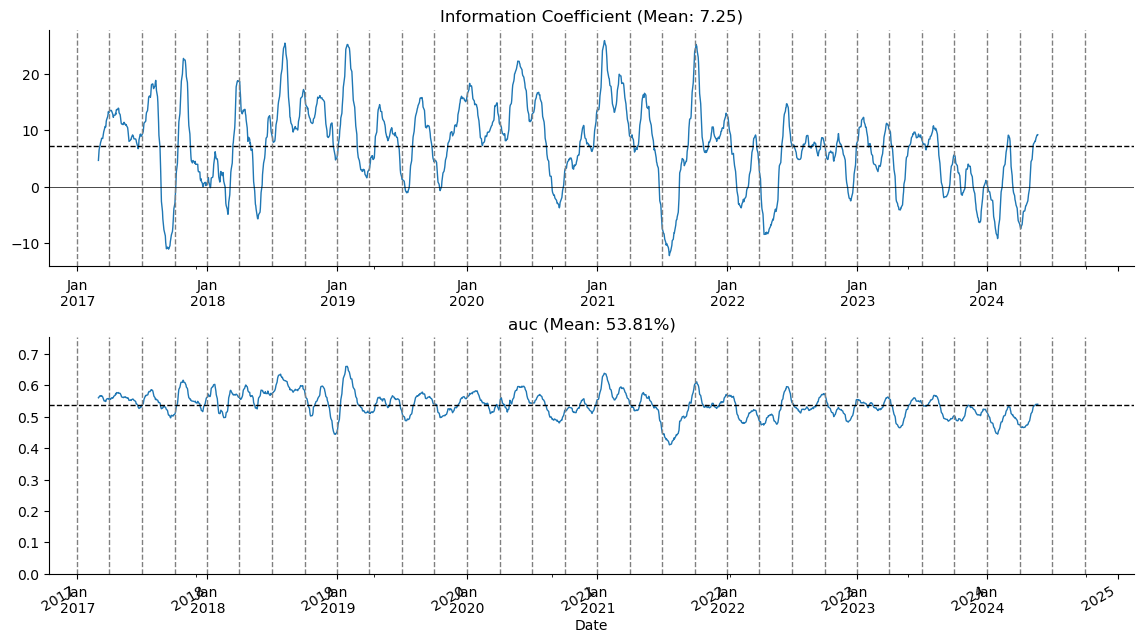

In [190]:
plot_utility.plot_rolling_ic(log_scores[log_scores.C==best_C], error_metric= "auc",label_every_n_months=3)

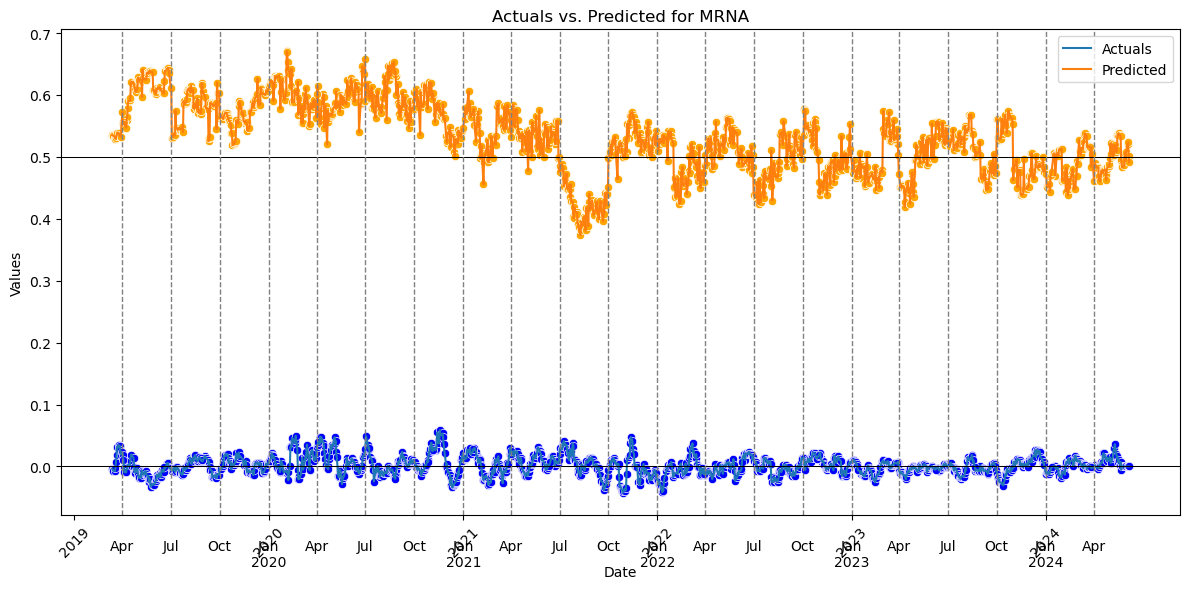

In [208]:
plot_utility.plot_actuals_predicted(log_predictions[log_predictions.C==best_C], "MRNA")


In [221]:
np.mean((log_predictions.predicted>0.3).astype(int) == log_predictions.label)

0.5069545589633127